In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# Are NFL Scouting Combine Metrics Meaningful Predictors of Quarterback Performance?
### DATASCI 151 Final Project Spring 2026
**Group Members:** Nicholas Huang [2627522],

---

## Introduction

The NFL relies on the NFL Combine, a week-long event where top collegiate football players perform a series of athletic and cognitive tests in front of teams scouts, as one of the primary ways to discern player skill and draft value. For quarterbacks, one of the most valuable positions in the game, the combine is a chance to showcase the necessary physical and processing skills that may ensure them a spot in the league. These tests include the 40-yard dash, measuring straight-line speed, vertical jump and 3-cone drill, measuring agility and explosiveness, the 20-yard shuttle, measuring short-bursts of speeds, and the Wonderlic Personnel Test, measuring coginitive ability. Teams scouts watch prospective players complete these tests which then informs their decisions on if and when they should select them in the NFL Draft. The central question motivating this project is: **do combine measurements actually predict how well a quarterback performs in real NFL games?**

Using a combination of datasets from the **NFL Play Statistics dataset** from Kaggle, an open-source data sharing platform, we first calculate three career performance statistics for each quarterback: completion percentage, touchdown-to-interception ratio, and passing yards per game. We then merge these statistics with each player's combine testing results and draft statistics to examine the correlations between combine metrics and on-field performance. Our results indicate that [FILL IN]

## Data Description

In [6]:
import pandas as pd #Importing Libraries
import numpy as np
import matplotlib.pyplot as plt

df_passer = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/passer.csv') #Importing Data
df_combine = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/combine.csv')
df_draft = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/draft.csv')
df_gp = pd.read_csv('https://raw.githubusercontent.com/tuckersampson/final_project_151/refs/heads/main/data/gameParticipation.csv')

print("Passer") #Generating stats for dataframe length and unique observations
print("Number of rows:", len(df_passer))
print("Unique playerIds:", df_passer["playerId"].nunique())
print("Unique playIds:", df_passer["playId"].nunique())

print("\nCombine")
print("Number of rows:", len(df_combine))
print("Unique playerIds:", df_combine["playerId"].nunique())
print("Unique positions:", df_combine["combinePosition"].nunique())

print("\nDraft")
print("Number of rows:", len(df_draft))
print("Unique playerIds:", df_draft["playerId"].nunique())
print("Unique draft years:", df_draft["draft"].nunique())
print("Unique rounds:", df_draft["round"].nunique())

print("\nGameParticipation")
print("Number of rows:", len(df_gp))
print("Unique playerIds:", df_gp["playerId"].nunique())
print("Unique gameIds:", df_gp["gameId"].nunique())

Passer
Number of rows: 397265
Unique playerIds: 755
Unique playIds: 397265

Combine
Number of rows: 10080
Unique playerIds: 10078
Unique positions: 26

Draft
Number of rows: 12140
Unique playerIds: 12119
Unique draft years: 43
Unique rounds: 12

GameParticipation
Number of rows: 423185
Unique playerIds: 5827
Unique gameIds: 995


From the twenty available tables in the entire datset, we selected four for our analysis. The first, **`df_passer`** contains one row per pass attempt for every quarterback across the 2004–2019 NFL seasons, containing around 397,000 individual attempts, recording the outcome of each throw.  **`df_combine`** contains the combine testing results for all players, 10,080 unique players, who have participated in the event since the late 1980s. **`df_draft`** records the draft year, round, and pick number for all drafted players, consisting of 12,140 players. **`df_gp`** logs each player's appearance in each game, which we use to count the number of games each quarterback played in order to compute yards per game.

### Merging Data

To merge our data, we first aggregated the `df_passer` play-by-play table into one row per player with career totals. We also join `gameParticipation` to obtain each QB's total games played utilizing inner join. Second, we merge the `combine` and `draft` tables on `playerId`, also on inner join, and keep only quarterbacks. Finally, we join the combine+draft table with the passer statistics, again on `playerId`, to give us a single table with one row per QB that we can conduct analysis on.

In [50]:
df_passer['pass_yards'] = df_passer['passLength'] * df_passer['passComp'] #Isolating only completed passes

qb_stats = df_passer.groupby('playerId').agg(attempts = ('passAtt', 'sum'), #Aggregating QB stats for each unique player
                                        completions = ('passComp', 'sum'),
                                        touchdowns = ('passTd', 'sum'),
                                        interceptions = ('passInt', 'sum'),
                                        total_yards = ('pass_yards','sum')).reset_index()

qb_games = (df_gp[df_gp['position'] == 'QB'].groupby(by = 'playerId')['gameId'].nunique()) #Counting games played per unique player

qb_stats = qb_stats.merge(qb_games, on='playerId', how='inner') #Merging games played and QB stats on inner, to preserve only players in QB stats

In [ ]:
combine = df_combine
draft = df_draft

combine_draft = pd.merge(left = combine, right = draft, how = "inner", on = "playerId")
combine_draft = combine_draft.query("combinePosition == 'QB'")

# Drop unused columns
combine_draft = combine_draft.drop(columns = ["combineId_x", "nameFirst_x", "nameLast_x", 
                                              "collegeId_x", "nflId_x", "college_x", "heightInches_x", 
                                              "weight_x", "playerProfileUrl_x", "homeCity_x", "homeState_x", 
                                              "homeCountry_x", "hsCity_x", "highSchool_x", "hsState_x", 
                                              "hsCountry_x", "draftTeam", "teamId", "nameFirst_y", 
                                              "nameLast_y", "nameFull_y", "collegeId_y", "nflId_y", 
                                              "combineId_y", "college_y", "heightInches_y", "weight_y", 
                                              "dob_y", "playerProfileUrl_y", "homeCity_y", "homeState_y", 
                                              "homeCountry_y", "highSchool_y", "hsCity_y", "hsState_y", 
                                              "hsCountry_y", "ageAtDraft_y", "position_y"])

passer_draft = pd.merge(left = combine_draft, right = qb_stats, how = "inner", on = "playerId")

### Cleaning Data

Our data required minimal cleaning. For `qb_stats`, we first examined the shape, data types, and unique values of each column. We used an inner join when merging the aggregated passer data with game participation counts, which excluded the 538 quarterbacks who appeared in `passer` but had no matching record in `gameParticipation`. We then used `query()` to filter out quarterbacks with fewer than 100 career pass attempts, as their career averages would not be representative of sustained NFL performance. Next we cleaned `combine_draft` and `passer_draft`. After dropping our unused columns, we found that many remaining columns consisted of almost entirely missing values - thus we dropped these columns. Next, we eliminated all players who were drafted after round 7, as rounds 8-12 only existed in the earlier years of the NFL. Now we can study draft data from 300 QBs and in-game data from 122 QBs.

In [52]:
n_rows, n_cols = qb_stats.shape #Computing stats for dataframe
print("# of rows:", n_rows)
print("# of columns:", n_cols)
print()
print(qb_stats.dtypes)
print()

print("Sample of games_played values:", pd.unique(qb_stats["gameId"])[:10])

qb_stats = qb_stats.query("attempts >= 100") #Only keeping players with over 100 passes

qb_stats['comp_pct'] = (qb_stats['completions'] / qb_stats['attempts'] * 100).round(2) #Computing QB stats of interest
qb_stats['td_int_ratio'] = (qb_stats['touchdowns'] / (qb_stats['interceptions'] + 1)).round(2)
qb_stats["yards_per_game"] = (qb_stats["total_yards"]  / qb_stats["gameId"]).round(2)

print("# of rows after cleaning:", len(qb_stats))
print()
print("Nulls remaining:")
print(qb_stats.isnull().sum())

# of rows: 217
# of columns: 7

playerId         int64
attempts         int64
completions      int64
touchdowns       int64
interceptions    int64
total_yards      int64
gameId           int64
dtype: object

Sample of games_played values: [20  7 61 14 49 34 12 19  1 45]
# of rows after cleaning: 167

Nulls remaining:
playerId          0
attempts          0
completions       0
touchdowns        0
interceptions     0
total_yards       0
gameId            0
comp_pct          0
td_int_ratio      0
yards_per_game    0
dtype: int64


In [ ]:
# Find # of missing values in each row
print(combine_draft.isnull().sum())
print(passer_draft.isnull().sum())

# Drop columns with too many missing values
combine_draft = combine_draft.drop(columns = ["combine60ydShuttle", "combineBench"])
passer_draft = passer_draft.drop(columns = ["combineHand", "combineArm", "combineBench", "combine60ydShuttle"])

# Removed rouds 8-12, as these rounds only existed in earlier years of the NFL
combine_draft.rename(columns = {"round" : "Round"}, inplace = True)
passer_draft.rename(columns = {"round" : "Round"}, inplace = True)
combine_draft = combine_draft.query('Round <= 7')
passer_draft = passer_draft.query('Round <= 7')

print("# of QBs after cleaning in combine_draft:", len(combine_draft))
print("# of QBs after cleaning in passer_draft:", len(passer_draft))

playerId                0
combineYear             0
combinePosition         0
combineHeight           0
combineWeight           0
combineHand           240
nameFull_x              0
position_x              0
dob_x                   0
ageAtDraft_x            0
combineArm            249
combine40yd            43
combineVert            65
combineBench          322
combineShuttle         79
combineBroad           67
combine3cone          157
combine60ydShuttle    339
combineWonderlic      186
draft                   0
round                  11
pick                    0
draftTradeValue         0
dtype: int64
playerId                0
combineYear             0
combinePosition         0
combineHeight           0
combineWeight           0
combineHand           132
nameFull_x              0
position_x              0
dob_x                   0
ageAtDraft_x            0
combineArm            132
combine40yd            12
combineVert            26
combineBench          129
combineShuttle         36

### Descriptive Statistics

The table below summarizes the three computed performance metrics and the five combine measurements we will use in our analysis. Combine metrics are shown for all QBs who have a recorded value.

In [ ]:
INSERT CODE FOR DESCRIPTIVE STATISTICS

: 

: 

: 

: 

: 

The correlation matrix below shows correlation coefficients between all numeric columns in our `combine_draft` dataset. We want to study which combine events or player atrtributes best correlate to the round they are picked. Better players are often picked earlier on in the draft, so we would expect negative correlation between player skill and the round in which they are picked. For example, there is a slight negative correlation (~0.353) between weight and round picked - meaning heavier quarterbacks are drafted slightly earlier than lighter ones on average. Perhaps heavier quarterbacks are more valuable.

In [54]:
display(combine_draft.corr(numeric_only = True).round(4))

,playerId,combineYear,combineHeight,combineWeight,combineHand,ageAtDraft_x,combineArm,combine40yd,combineVert,combineShuttle,combineBroad,combine3cone,combineWonderlic,draft,Round,pick,draftTradeValue
playerId,1.0000,1.0000,0.1925,0.3912,0.1758,-0.0117,0.4486,-0.1988,0.1437,-0.1728,0.2891,-0.4321,0.1582,1.0000,-0.0818,0.0085,0.0697
combineYear,1.0000,1.0000,0.1927,0.3914,0.1765,-0.0119,0.4492,-0.1990,0.1439,-0.1729,0.2893,-0.4324,0.1582,1.0000,-0.0826,0.0076,0.0703
combineHeight,0.1925,0.1927,1.0000,0.6025,0.3099,-0.0360,0.4487,0.2536,-0.1593,0.2241,-0.0356,0.0672,0.1210,0.1927,-0.1983,-0.1794,0.1876
combineWeight,0.3912,0.3914,0.6025,1.0000,0.4953,-0.1138,0.3839,0.0528,0.0591,0.0394,0.1130,-0.0549,0.0271,0.3914,-0.2332,-0.1814,0.2311
combineHand,0.1758,0.1765,0.3099,0.4953,1.0000,0.0076,0.2433,0.0142,0.1408,-0.0550,0.0841,0.4260,NaN,0.1765,-0.3738,-0.3408,0.3331
ageAtDraft_x,-0.0117,-0.0119,-0.0360,-0.1138,0.0076,1.0000,0.1339,0.1710,-0.1433,-0.0183,-0.2335,0.0718,-0.0245,-0.0119,0.2534,0.2587,-0.3105
combineArm,0.4486,0.4492,0.4487,0.3839,0.2433,0.1339,1.0000,0.0813,0.1548,-0.0332,0.2262,0.2266,NaN,0.4492,-0.2764,-0.2004,0.3157
combine40yd,-0.1988,-0.1990,0.2536,0.0528,0.0142,0.1710,0.0813,1.0000,-0.6920,0.5007,-0.6697,0.4634,0.1711,-0.1990,0.2132,0.2020,-0.2401
combineVert,0.1437,0.1439,-0.1593,0.0591,0.1408,-0.1433,0.1548,-0.6920,1.0000,-0.5377,0.7314,-0.3438,-0.0900,0.1439,-0.2649,-0.2316,0.2057
combineShuttle,-0.1728,-0.1729,0.2241,0.0394,-0.0550,-0.0183,-0.0332,0.5007,-0.5377,1.0000,-0.4299,0.5267,-0.1128,-0.1729,0.2074,0.1662,-0.1055


Not only do we want to assess the strenghts of these relationships, but we want to visualize the relationships themselves. Below we can see how some player metrics lead to earlier drafting:

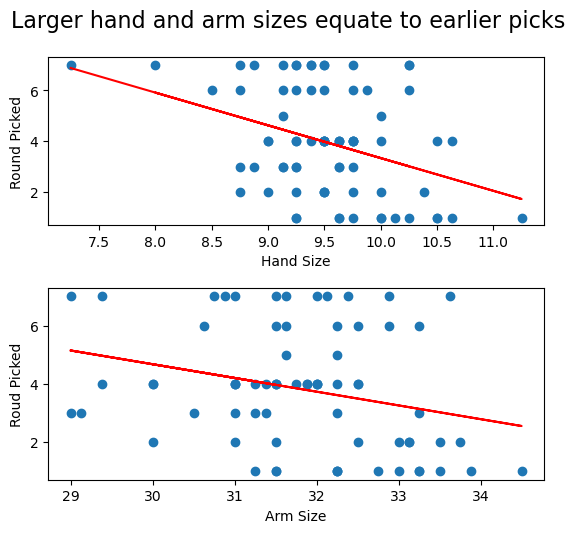

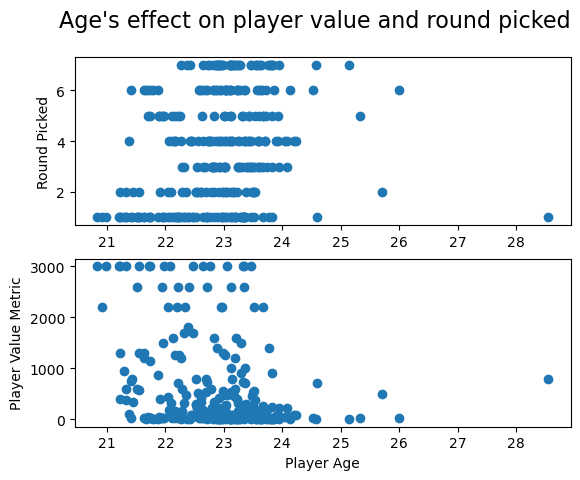

In [109]:
# Find regression coefficients between hand size and round picked, as well as arm size and roud picked
model = smf.ols(formula = "Round ~ combineHand", data = combine_draft)
model2 = smf.ols(formula = "Round ~ combineArm", data = combine_draft)
coeffs = model.fit().params
coeffs2 = model2.fit().params

a = coeffs["Intercept"]
b = coeffs["combineHand"]
aa = coeffs2["Intercept"]
bb = coeffs2["combineArm"]

# Get predicted round picked values based on these coefficients
predicted_round = np.array(combine_draft["combineHand"])
predicted_round = (b * predicted_round) + a
predicted_round_2 = np.array(combine_draft["combineArm"])
predicted_round_2 = (bb * predicted_round_2) + aa

# Plot hand size and arm size vs round
figure, [a1, a2] = plt.subplots(2, 1)
a1.scatter(combine_draft["combineHand"], combine_draft["Round"])
a1.plot(combine_draft["combineHand"], predicted_round, color = "red")
a1.set_xlabel("Hand Size")
a1.set_ylabel("Round Picked")
a2.scatter(combine_draft["combineArm"], combine_draft["Round"])
a2.plot(combine_draft["combineArm"], predicted_round_2, color = "red")
a2.set_xlabel("Arm Size")
a2.set_ylabel("Roud Picked")
a2.set_position([0.125, 0, 0.775, 0.4])
figure.suptitle("Larger hand and arm sizes equate to earlier picks", fontsize = 16)
plt.show()

# Plot player age vs player value and round picked
fig, [ax1, ax2] = plt.subplots(2, 1)
ax1.scatter(combine_draft["ageAtDraft_x"], combine_draft["Round"])
ax1.set_ylabel("Round Picked")
ax2.scatter(combine_draft["ageAtDraft_x"], combine_draft["draftTradeValue"])
ax2.set_xlabel("Player Age")
ax2.set_ylabel("Player Value Metric")
fig.suptitle("Age's effect on player value and round picked", fontsize = 16)
plt.show()

---
## Results

### Correlation Between Combine Metrics and Draft Pick

Hand size and arm size both predict the round in which one will get drafted: the longer arms and the bigger your hands, the earlier you will be drafted. These things are crucial for being a quarterback. Larger hands can allow you to handle the ball easier, making the player more efficient catching snaps and better at throwing overall. Similarly, arm length provides a biomechanical advantage when throwing, increasing distance. It also correlates with height, meaning taller QBs might be more valuable.

Below this, we can see age's effect on player value and round picked. In the first plot, it appears younger players are picked slightly earlier. This is confirmed in the next plot: it appears younger players have more value when being picked in the draft.

Although the sample size is small, our analyses show that arm size, hand size, and age are predictors of draft pick. Younger people with longer arms and bigger hands tend to be drafted earlier.

### Correlation Between Combine Metrics and QB Performance

In [ ]:
INSERT CODE FOR GENERATING CORRELATION AND SUMMARY TABLES

: 

: 

: 

: 

: 

**Interpretation:** 

INSERT INTERPRETATION OF DATA

---
## Discussion

INSERT DISCUSSION OF DATA